<a href="https://colab.research.google.com/github/guadalupe-santos/ALC-Laboratorios/blob/main/Laboratorio_N%E2%97%A6_02_Transformaciones_Lineales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EJercicio 1

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def pointsGrid(esquinas):
    # crear 10 lineas horizontales
    [w1, z1] = np.meshgrid(np.linspace(esquinas[0,0], esquinas[1,0], 46),
                        np.linspace(esquinas[0,1], esquinas[1,1], 10))

    [w2, z2] = np.meshgrid(np.linspace(esquinas[0,0], esquinas[1,0], 10),
                        np.linspace(esquinas[0,1], esquinas[1,1], 46))

    w = np.concatenate((w1.reshape(1,-1),w2.reshape(1,-1)),1)
    z = np.concatenate((z1.reshape(1,-1),z2.reshape(1,-1)),1)
    wz = np.concatenate((w,z))

    return wz

def proyectarPts(T, wz):
    assert(T.shape == (2,2)) # chequeo de matriz 2x2
    assert(T.shape[1] == wz.shape[0]) # multiplicacion matricial valida
    x = 0
    y = 0
    x = T[0]@wz
    y = T[1]@wz
    xy = []
    xy.append(x)
    xy.append(y)
    xy = np.array(xy)
    return xy
T = np.array([[1/2,0],[0,1/2]])
wz = np.array([2,2])
print('f = ',proyectarPts(T,wz))
T_inversa = np.array([[2,0],[0,2]])
print('f_inversa = ',proyectarPts(T_inversa,wz))

f =  [1. 1.]
f_inversa =  [4 4]


Ejercicio 2 - Reescalamiento

In [3]:
# T = [aw,0],[0,bz]
# T^-1 = [w/a,0],[0,z/b]
#Canónicos
wz = np.array([1,0])
T = np.array([[2,0],[0,3]])
T_inversa = np.array([[1/2,0],[0,1/3]])
print('f_canonicos = ',proyectarPts(T,wz))
print('f_canocicos_inversa = ',proyectarPts(T_inversa,wz))

#Ptos arbitrarios
wz = np.array([4,2])
T = np.array([[2,0],[0,3]])
T_inversa = np.array([[1/2,0],[0,1/3]])
print('f_pto_arbitrario = ',proyectarPts(T,wz))
print('f_pto_arbitrario_inversa = ',proyectarPts(T_inversa,wz))

#Circunferencia radio=2
wz = np.array([2*np.cos(8),2*np.sin(8)])
T = np.array([[2,0],[0,3]])
T_inversa = np.array([[1/2,0],[0,1/3]])
print('f_circunferencia = ',proyectarPts(T,wz))
print('f_circunferencia_inversa = ',proyectarPts(T_inversa,wz))

""" Análisis resultados
f_canonicos =  [2 0] el eje x se estiro el doble
f_canocicos_inversa =  [0.5 0. ] su inversa lo dividió a la mitad
f_pto_arbitrario =  [8 6] el eje x se duplicó y el y se triplicó
f_pto_arbitrario_inversa =  [2.         0.66666667] eje x se dividó a la mitad y el y por tres
f_circunferencia =  [-0.58200014  5.93614948] forma elipse
f_circunferencia_inversa =  [-0.14550003  0.65957216] deforma más un eje que el otro """

f_canonicos =  [2 0]
f_canocicos_inversa =  [0.5 0. ]
f_pto_arbitrario =  [8 6]
f_pto_arbitrario_inversa =  [2.         0.66666667]
f_circunferencia =  [-0.58200014  5.93614948]
f_circunferencia_inversa =  [-0.14550003  0.65957216]


' Análisis resultados\nf_canonicos =  [2 0] el eje x se estiro el doble\nf_canocicos_inversa =  [0.5 0. ] su inversa lo dividió a la mitad\nf_pto_arbitrario =  [8 6] el eje x se duplicó y el y se triplicó\nf_pto_arbitrario_inversa =  [2.         0.66666667] eje x se dividó a la mitad y el y por tres\nf_circunferencia =  [-0.58200014  5.93614948] forma elipse \nf_circunferencia_inversa =  [-0.14550003  0.65957216] deforma más un eje que el otro '

Ejercicio 3 - Deformación

In [ ]:
#a) T = [1 c],[d 1]

**Cálculo de la inversa:**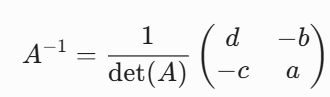

In [ ]:
# T^-1 = 1/(1-dc)*([1 -c][-d 1])
# T^-1 = [1/(1-dc) -c/(1-dc)],[-d/(1-dc) 1/(1-dc)]

In [10]:
# b)
b = 1
T = np.array([[1,b],[0,1]])
# esta transformación deforma los puntos en el eje y

array([1, 0])

In [4]:
def vistform(T, wz, titulo=''):
    # transformar los puntos de entrada usando T
    xy = proyectarPts(T, wz)
    if xy is None:
        print('No fue implementada correctamente la proyeccion de coordenadas')
        return
    # calcular los limites para ambos plots
    minlim = np.min(np.concatenate((wz, xy), 1), axis=1)
    maxlim = np.max(np.concatenate((wz, xy), 1), axis=1)

    bump = [np.max(((maxlim[0] - minlim[0]) * 0.05, 0.1)),
            np.max(((maxlim[1] - minlim[1]) * 0.05, 0.1))]
    limits = [[minlim[0]-bump[0], maxlim[0]+bump[0]],
               [minlim[1]-bump[1], maxlim[1]+bump[1]]]

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.suptitle(titulo)
    grid_plot(ax1, wz, limits, 'w', 'z')
    grid_plot(ax2, xy, limits, 'x', 'y')

def grid_plot(ax, ab, limits, a_label, b_label):
    ax.plot(ab[0,:], ab[1,:], '.')
    ax.set(aspect='equal',
           xlim=limits[0], ylim=limits[1],
           xlabel=a_label, ylabel=b_label)

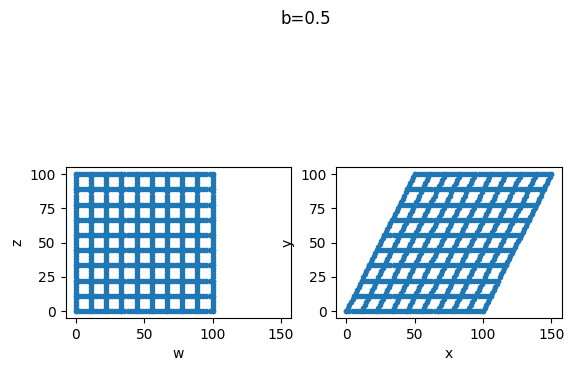

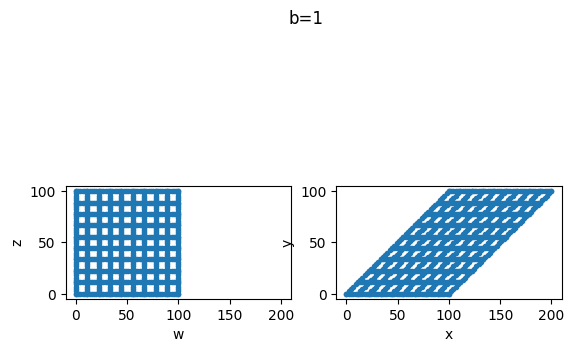

In [13]:
# Cuadrado 100x100
esquinas = np.array([[100,0],[0,100]])
wz = pointsGrid(esquinas) #arma la grilla de ptos

#Pruebas variando b
b_1 = 0.5
T_1 = np.array([[1,b_1],[0,1]])

vistform(T_1, wz, 'b=0.5')
plt.show()
# Llama a proyectarPts, grafica antes y después

b_2 = 1
T_2 = np.array([[1,b_2],[0,1]])

vistform(T_2, wz, 'b=1')
plt.show()

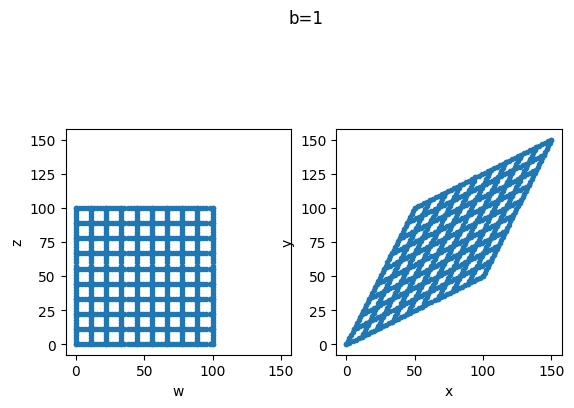

"esquinas = np.array([[100,0],[0,100]])\nwz = pointsGrid(esquinas) \nb_1 = 0.5\nT_1 = np.array([[1,b_1],[b_1,1]])\n\nvistform(T_1, wz, 'b=0.5')\nplt.show()\n\n#Ahora también modfica en el eje x\n\nb_2 = 1\nT_2 = np.array([[1,b_2],[b_2,1]])\n\nvistform(T_2, wz, 'b=1')\nplt.show()"

In [7]:
#c)
esquinas = np.array([[100,0],[0,100]])
wz = pointsGrid(esquinas)
b_1 = 0.5
T_1 = np.array([[1,b_1],[b_1,1]])

vistform(T_1, wz, 'b=0.5')
plt.show()

#Ahora también modfica en el eje x

b_2 = 1
T_2 = np.array([[1,b_2],[b_2,1]])

vistform(T_2, wz, 'b=1')
plt.show()

Ejercicio 2 - Reescalamiento (gráfico)

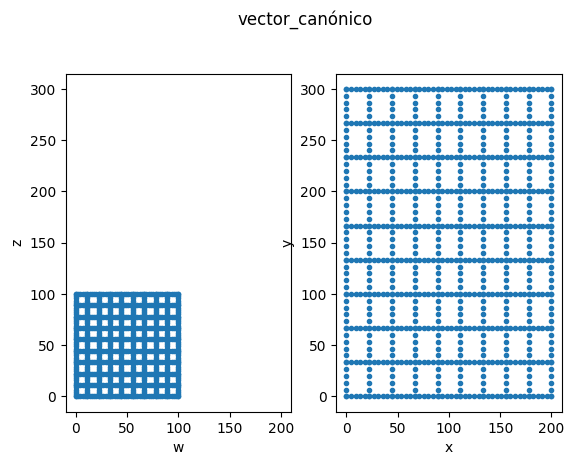

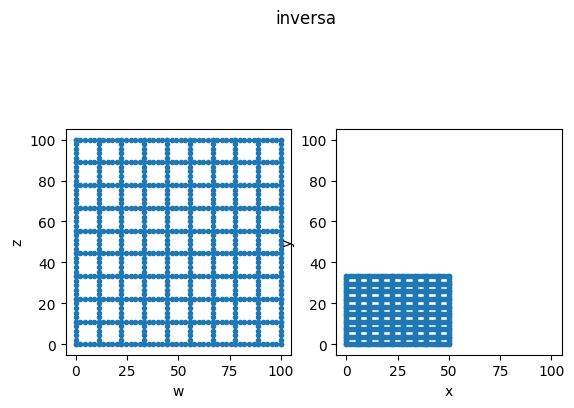

In [6]:
#Grafico las modificaciones
def visualizacion(T,wz,titulo=''):
  wz = pointsGrid(wz)
  vistform(T, wz, titulo)
  plt.show()
visualizacion(np.array([[2,0],[0,3]]),np.array([[100,0],[0,100]]),'vector_canónico')
visualizacion(np.array([[1/2,0],[0,1/3]]),np.array([[100,0],[0,100]]),'inversa')


Ejercicio 4 - Rotación

e1 (eje X) -> (1 0): cateto adyacente= cos(θ), cateto opuesto= sen(θ)
e2 (eje y): cateto adyacente= -sen(θ), cateto opuesto= cos(θ)  
***Cateto opuesto a θ: mide sen(θ)
Cateto adyacente a θ: mide cos(θ)***

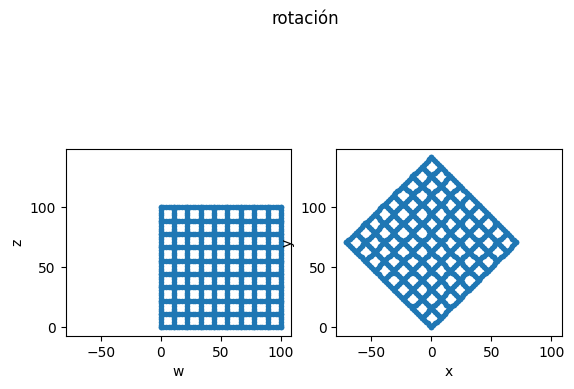

In [19]:
#T = (a(θ) b(θ)
#      c(θ) d(θ))
# T = (cos(θ) -sen(θ)
#      sen(θ) cos(θ))
θ = 0.25*np.pi
visualizacion(np.array([[np.cos(θ), -np.sin(θ)],[np.sin(θ),np.cos(θ)]]),np.array([[100,0],[0,100]]),'rotación')
#solo rota, no cambia de tamaño

Ejercicio 5 - Rotación y reescalamiento
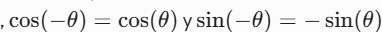

In [ ]:
#a)
# t1 = np.array([[np.cos(θ), -np.sin(θ)],[np.sin(θ),np.cos(θ)]])
# t2 = np.array([2,0],[0,3])
# t3 = np.array([[np.cos(θ),-np.sen(θ)],[np.sen(θ), -np.cos(θ)]])
# con θ = 0.25*np.pi

***COMPOSICIÓN MATRICIAL***
**La concatenación se evalúa de derecha a izquierda, resolviendo el producto interno:**
T = t3.(t2.(t1.v))

[[2.5 0.5]
 [0.5 2.5]]


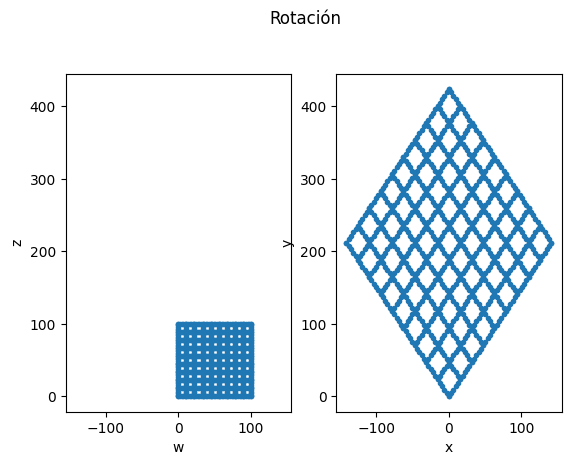

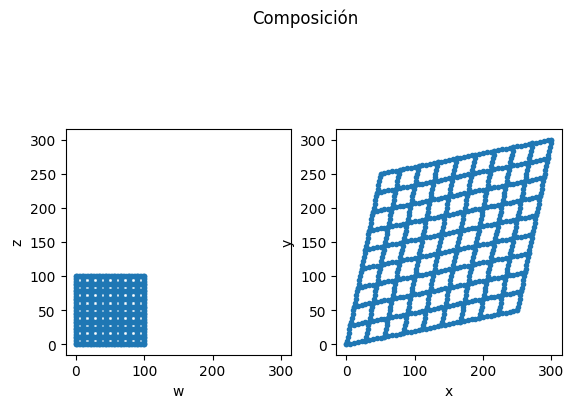

In [35]:
t1 = np.array([[np.cos(0.25*np.pi), -np.sin(0.25*np.pi)],[np.sin(0.25*np.pi),np.cos(0.25*np.pi)]])
t2 = np.array([[2,0],[0,3]])
t3 = np.array([[np.cos(0.25*np.pi),np.sin(0.25*np.pi)],[-np.sin(0.25*np.pi), np.cos(0.25*np.pi)]])
T = t3 @ (t2 @ t1)
print(T)
visualizacion(t2@t1,np.array([[100,0],[0,100]]),'Rotación y reescala')
visualizacion(T,np.array([[100,0],[0,100]]),'Composición')


In [ ]:
#b)